In [5]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [11]:
# DATA
data = pd.read_csv('/home/coder/cuco_bf_mhashing/data/b256_bf_bench.csv')

benchmarks = ['bloom_filter_contains_unique_size',
              'arrow_bloom_filter_contains_unique_size',
              'pfp_bloom_filter_contains_unique_size']
data = data[data['Benchmark'].isin(benchmarks)]

In [12]:
# MACHINE CONFIG
L2_bytes = 40 * 1024 * 1024  # 40 MiB
log_L2_bytes = math.log2(L2_bytes)
L1_bytes = 192 * 1024  # 192 MiB
log_L1_bytes = math.log2(L1_bytes)

In [13]:
# PLOT CONFIG
palette = sns.color_palette("magma", n_colors=data['Benchmark'].nunique())
sns.set_style('whitegrid')
sns.set_context('talk')

In [16]:
# PROBE THROUGHPUT
data['ProbeThroughput(GK/s)'] = data['Elem/s (elem/sec)'] / \
    (1024 * 1024 * 1024)

# LOG FILTER SIZE
data['LogFilterSize(B)'] = data['FilterSizeMB'].apply(
    lambda x: math.log2(x * 1024 * 1024))
max_log_filter_size = int(data['LogFilterSize(B)'].max())
min_log_filter_size = int(data['LogFilterSize(B)'].min())

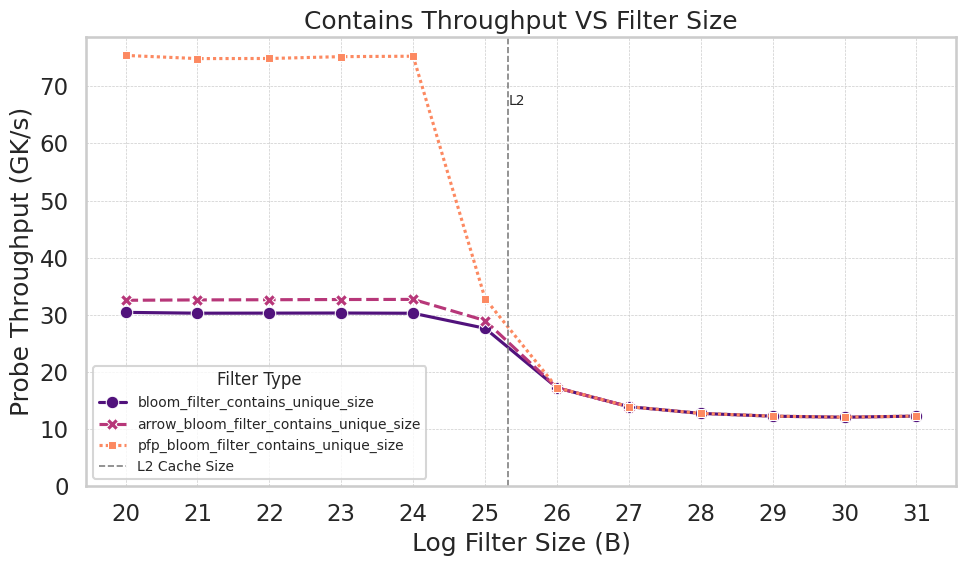

In [19]:
# PLOT
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(
    data=data,
    x='LogFilterSize(B)',
    y='ProbeThroughput(GK/s)',
    hue='Benchmark',
    style='Benchmark',
    markers=True,
    ax=ax,
    palette=palette)

# Add L2 and L1 lines
ax.axvline(log_L2_bytes, color='grey',
           linestyle='--', label='L2 Cache Size', linewidth=1.2)
# ax.axvline(log_L1_bytes, color='grey',
#            linestyle='--', label='L1 Cache Size', linewidth=1.2)

ax.set_title(f'Contains Throughput VS Filter Size')
ax.set_xlabel('Log Filter Size (B)')
ax.set_ylabel('Probe Throughput (GK/s)')
ax.set_ylim(bottom=0)
ax.set_xticks(range(min_log_filter_size, max_log_filter_size + 1))
ax.grid(True, linestyle='--', linewidth=0.5)
ax.legend(title='Filter Type',
          title_fontsize='12',
          fontsize='10',
          loc='lower left')

# Add annotations for L2 and L1 cache sizes
ax.annotate('L2', (log_L2_bytes, ax.get_ylim()[1] * 0.85), fontsize=10)
# ax.annotate('L1', (log_L1_bytes, ax.get_ylim()[1] * 0.85), fontsize=10)

plt.tight_layout()
plt.show()